#### 1. Loading the Dataset 

In [7]:
from sklearn import datasets
data = datasets.load_breast_cancer()

#### 2. Checking the Sample and Target Sizes

In [10]:
X = data.data
y = data.target
print(X.shape)
print(y.shape)
print(X.shape[0] == len(y)) 


(569, 30)
(569,)
True


#### 3. Splitting the Data for Training and Testing

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=11, test_size=0.25)

#### 5. Training and Testing Set Sizes

In [12]:
print('Training set size:', X_train.shape[0])
print('Testing set size:', X_test.shape[0])

Training set size: 426
Testing set size: 143


#### 6. Creating the Model (GaussianNB)

In [13]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

#### 7. Training the Model

In [14]:
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


#### 8. Predicting

In [15]:
predicted = nb.predict(X_test)
print('Predicted:', predicted[:20])
print('Expected: ', y_test[:20])

Predicted: [0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0]
Expected:  [0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0]


#### 9. Estimator Method score

In [16]:
print('Accuracy (test set):', nb.score(X_test, y_test))
print('Accuracy (training set):', nb.score(X_train, y_train))

Accuracy (test set): 0.951048951048951
Accuracy (training set): 0.9366197183098591


#### 10. Confusion Matrix

In [17]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(y_true=y_test, y_pred=predicted)
print('Confusion Matrix:')
print(confusion)

Confusion Matrix:
[[44  6]
 [ 1 92]]


#### 11. Classification Report

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=predicted, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



#### 12. Visualizing the Confusion Matrix

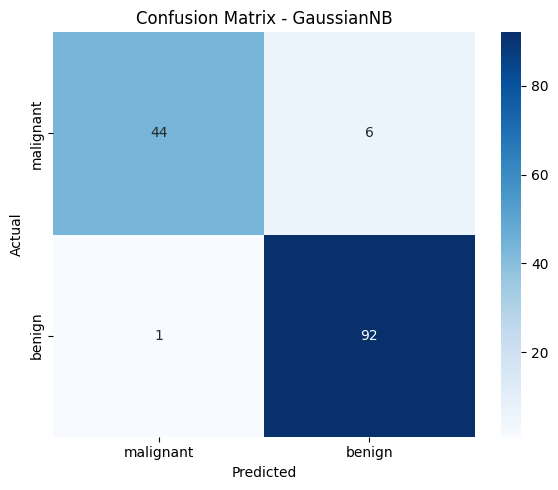

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - GaussianNB')
plt.tight_layout()
plt.show()

#### 13. K-Fold Cross-Validation

Using the KFold Object with Function cross_val_score:

In [20]:
from sklearn.model_selection import KFold
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

from sklearn.model_selection import cross_val_score
breast_cancer = data  # alias for requirement's variable name
scores = cross_val_score(estimator=nb, X=breast_cancer.data,
     y=breast_cancer.target, cv=kfold)
print('Scores:', scores)
print(f'Mean accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})')

Scores: [0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]
Mean accuracy: 0.9385 (+/- 0.0550)


#### 14. Running Multiple Models to Find the Best One

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

estimators = {
    'GaussianNB': nb,
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(solver='lbfgs', max_iter=10000),
    'SVC': SVC(gamma='scale')
}

results = {}
for name, estimator in estimators.items():
    kfold = KFold(n_splits=10, random_state=11, shuffle=True)
    scores = cross_val_score(estimator=estimator, X=data.data, y=data.target, cv=kfold)
    mean_score = scores.mean()
    results[name] = mean_score
    print(f'{name}: mean accuracy = {mean_score:.4f} (+/- {scores.std() * 2:.4f})')

best_name = max(results, key=results.get)
print(f'\nBest model: {best_name} (mean accuracy = {results[best_name]:.4f})')

GaussianNB: mean accuracy = 0.9385 (+/- 0.0550)
KNeighborsClassifier: mean accuracy = 0.9279 (+/- 0.0401)
LogisticRegression: mean accuracy = 0.9526 (+/- 0.0544)
SVC: mean accuracy = 0.9192 (+/- 0.0705)

Best model: LogisticRegression (mean accuracy = 0.9526)
